# Notebook 02 — Vectors, Dot Products, and Norms

**Module:** 04 — Linear Algebra  
**Notebook:** 02 of 10  
**Prerequisites:** NB01  
**Time estimate:** 60 minutes

---
## Step 1 — Motivation

A gene's expression profile across samples is a vector in $\mathbb{R}^S$. How similar
are two genes? The dot product tells you. How 'extreme' is a sample's expression?
The norm tells you. Cosine similarity built from these two operations powers co-expression
analysis, sequence alignment scoring, and k-nearest-neighbor clustering of cells.

---
## Step 2 — Intuition

**Dot product:** $\mathbf{a} \cdot \mathbf{b} = \|\mathbf{a}\| \|\mathbf{b}\| \cos\theta$.
Large dot product → vectors point in similar directions → genes are co-expressed.
Zero dot product → vectors are orthogonal → genes are independent.

**Norm:** the 'length' of a vector. $L_2$ norm = Euclidean distance from origin.
$L_1$ norm = Manhattan distance. Both measure how 'big' a vector is, but in different ways.

**Cosine similarity:** normalize the dot product by both norms — measures angle, not magnitude.
Two genes with high cosine similarity always go up and down together, regardless of
their absolute expression levels.

---
## Step 3 — Biological Background

**Gene expression vectors:**
- Gene $g$ has an expression profile $\mathbf{x}_g \in \mathbb{R}^S$ across $S$ samples.
- If two genes are regulated by the same transcription factor, their profiles are
  nearly parallel → high cosine similarity.

**Sequence alignment scoring:**
- BLAST dot product: count matching k-mers (words) between query and database sequence.
  A high count = likely homology. The High-Scoring Segment Pairs in BLAST are computed
  by this dot product in k-mer space.

**Single-cell nearest neighbors:**
- UMAP and Seurat's graph construction both compute $k$-nearest neighbors of cells using
  Euclidean distance (or cosine similarity after normalization) in high-dimensional
  expression space.

---
## Step 4 — Mathematical Explanation

**Dot product:**
$$\mathbf{a} \cdot \mathbf{b} = \sum_{i=1}^n a_i b_i = \mathbf{a}^\top \mathbf{b}$$

**$L_p$ norms:**
$$\|\mathbf{x}\|_p = \left(\sum_{i=1}^n |x_i|^p\right)^{1/p}$$

- $p=1$: $\|\mathbf{x}\|_1 = \sum_i |x_i|$ — sum of absolute values
- $p=2$: $\|\mathbf{x}\|_2 = \sqrt{\sum_i x_i^2}$ — Euclidean length
- $p=\infty$: $\|\mathbf{x}\|_\infty = \max_i |x_i|$ — maximum absolute entry

**Cosine similarity:**
$$\cos(\mathbf{a}, \mathbf{b}) = \frac{\mathbf{a} \cdot \mathbf{b}}{\|\mathbf{a}\|_2 \|\mathbf{b}\|_2} \in [-1, 1]$$

**Cauchy-Schwarz inequality:** $|\mathbf{a} \cdot \mathbf{b}| \leq \|\mathbf{a}\|_2 \|\mathbf{b}\|_2$,
so cosine similarity is always in $[-1, 1]$.

---
## Step 6 — Python Implementation

In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
# Cell 6.1 — Dot product and norms from scratch
def dot_product(a: np.ndarray, b: np.ndarray) -> float:
    return np.sum(a * b)

def lp_norm(x: np.ndarray, p: float) -> float:
    if p == np.inf:
        return np.max(np.abs(x))
    return np.sum(np.abs(x)**p)**(1/p)

def cosine_similarity(a: np.ndarray, b: np.ndarray) -> float:
    return dot_product(a, b) / (lp_norm(a, 2) * lp_norm(b, 2))

# Gene expression vectors (20 samples)
rng = np.random.default_rng(42)
gene_A = rng.normal(5, 1, 20)           # housekeeping gene — moderate, stable
gene_B = gene_A * 1.5 + rng.normal(0, 0.3, 20)  # co-expressed with A
gene_C = rng.normal(5, 1, 20)           # independent gene
gene_D = -gene_A + rng.normal(0, 0.3, 20)       # anti-correlated with A

print(f"Cosine similarity (A, B) = {cosine_similarity(gene_A, gene_B):.4f}  [co-expressed]")
print(f"Cosine similarity (A, C) = {cosine_similarity(gene_A, gene_C):.4f}  [independent]")
print(f"Cosine similarity (A, D) = {cosine_similarity(gene_A, gene_D):.4f}  [anti-correlated]")

print(f"\nNorms of gene_A:")
print(f"  L1 = {lp_norm(gene_A, 1):.3f}")
print(f"  L2 = {lp_norm(gene_A, 2):.3f}  (vs np.linalg.norm: {np.linalg.norm(gene_A):.3f})")
print(f"  L∞ = {lp_norm(gene_A, np.inf):.3f}")

Cosine similarity (A, B) = 0.9995  [co-expressed]
Cosine similarity (A, C) = 0.9713  [independent]
Cosine similarity (A, D) = -0.9991  [anti-correlated]

Norms of gene_A:
  L1 = 99.341
  L2 = 22.535  (vs np.linalg.norm: 22.535)
  L∞ = 6.127


In [3]:
# Cell 6.2 — All-pairs cosine similarity matrix (co-expression matrix)
# Build a synthetic 100-gene expression matrix
n_genes, n_samples = 100, 30
# 4 gene modules: each module's genes co-vary
n_modules = 4
gene_module = rng.choice(n_modules, n_genes)
module_signal = rng.normal(0, 2, (n_modules, n_samples))
expr = module_signal[gene_module] + rng.normal(0, 0.5, (n_genes, n_samples))

# Cosine similarity matrix: (n_genes, n_genes)
norms = np.linalg.norm(expr, axis=1, keepdims=True)
cos_sim_matrix = (expr @ expr.T) / (norms @ norms.T + 1e-12)
cos_sim_matrix = np.clip(cos_sim_matrix, -1, 1)

print(f"Co-expression (cosine similarity) matrix: {cos_sim_matrix.shape}")
print(f"Diagonal (self-similarity): {np.diag(cos_sim_matrix)[:5].round(6)}  [should be 1.0]")
print(f"Mean within-module similarity: {cos_sim_matrix[gene_module==0][:, gene_module==0].mean():.3f}")
print(f"Mean cross-module similarity:  {cos_sim_matrix[gene_module==0][:, gene_module==1].mean():.3f}")

Co-expression (cosine similarity) matrix: (100, 100)
Diagonal (self-similarity): [1. 1. 1. 1. 1.]  [should be 1.0]
Mean within-module similarity: 0.955
Mean cross-module similarity:  0.075


---
## Step 7 — Visualization

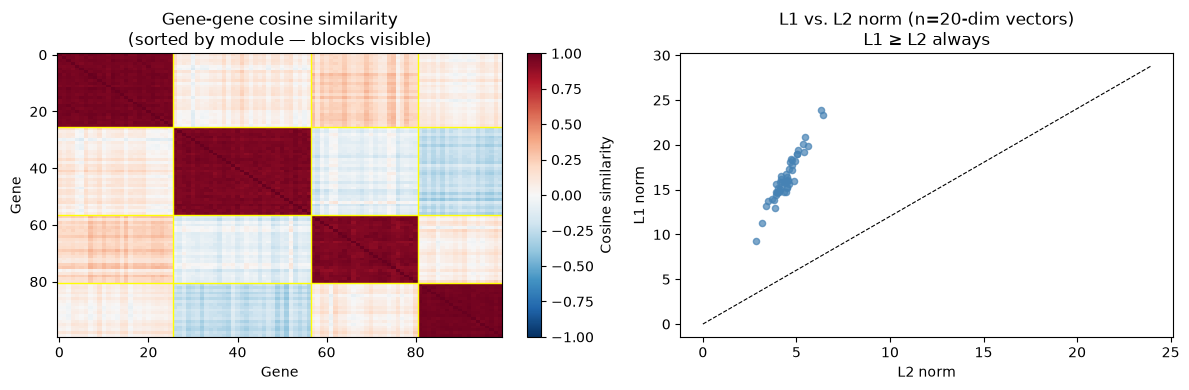

In [15]:
# Cell 7.1 — Co-expression matrix and norm comparison
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Panel 1: Co-expression matrix (sorted by module)
ax = axes[0]
order = np.argsort(gene_module)
im = ax.imshow(cos_sim_matrix[np.ix_(order, order)], aspect='auto',
               cmap='RdBu_r', vmin=-1, vmax=1, interpolation='none')
plt.colorbar(im, ax=ax, fraction=0.046, label='Cosine similarity')
# Draw module boundaries
boundaries = np.where(np.diff(np.sort(gene_module)))[0] + 1
for b in boundaries:
    ax.axhline(b - 0.5, color='yellow', lw=1)
    ax.axvline(b - 0.5, color='yellow', lw=1)
ax.set_xlabel('Gene'); ax.set_ylabel('Gene')
ax.set_title('Gene-gene cosine similarity\n(sorted by module — blocks visible)')

# Panel 2: Norm comparison for 50 random gene vectors
ax = axes[1]
test_vecs = rng.normal(0, 1, (50, 20))
l1_norms = [lp_norm(v, 1) for v in test_vecs]
l2_norms = [lp_norm(v, 2) for v in test_vecs]
ax.scatter(l2_norms, l1_norms, s=20, alpha=0.7, color='steelblue')
# Cauchy-Schwarz lower bound: L1 >= L2
lim = max(max(l1_norms), max(l2_norms))
ax.plot([0, lim], [0, np.sqrt(20) * lim / lim * max(l2_norms)], 'k--',
        lw=0.8, label='L1 ≤ √n · L2')
ax.set_xlabel('L2 norm'); ax.set_ylabel('L1 norm')
ax.set_title('L1 vs. L2 norm (n=20-dim vectors)\nL1 ≥ L2 always')

plt.tight_layout()
plt.show()

---
## Step 8 — Exercises

1. Implement `cosine_similarity(a, b)` from scratch. Verify it returns exactly 1.0
   when a=b and approximately 0 for two independent random vectors (n=1000).
2. Prove analytically that cosine similarity ∈ [-1, 1] using the Cauchy-Schwarz inequality.
3. When is cosine similarity preferable to Euclidean distance for comparing gene
   expression vectors? When is Euclidean distance preferable?
4. The L1 norm of a sparse vector (many zeros) is equal to the sum of its non-zero
   entries. How does this make L1 norm useful for regularization (LASSO)?

---
## Quiz — Active Recall

1. Write the dot product formula. What does a zero dot product mean geometrically?
2. What is the L2 norm of a vector? Write the formula.
3. What is cosine similarity? How is it computed from dot product and norms?
4. Two genes have expression vectors that differ only in scale (gene B = 2 × gene A).
   What is their Euclidean distance? What is their cosine similarity?
5. Write the Cauchy-Schwarz inequality.

---
## Reflection

**Date completed:** ____________________

> *[Can you explain the difference between Euclidean distance and cosine similarity to a biologist? When does the distinction matter?]*

---
*Next: `03_matrices_and_matrix_multiplication.ipynb`*